<a href="https://colab.research.google.com/github/tauqeer-jetcom/ML_PROJECTS_1-61023748031/blob/main/Hybrid_Machine_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("apple_stock_data.csv")
df

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23
...,...,...,...,...,...,...
2513,03/05/2010,$31.2786,224647427,$30.7057,$31.3857,$30.6614
2514,03/04/2010,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2515,03/03/2010,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2516,03/02/2010,$29.8357,141486282,$29.99,$30.1186,$29.6771


In [3]:
df.columns = df.columns.str.strip()

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

df = df[['Close/Last']]

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2518 entries, 2020-02-28 to 2010-03-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Close/Last  2518 non-null   object
dtypes: object(1)
memory usage: 39.3+ KB


,0
Close/Last,0


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Clean 'Close/Last' column: remove '$' and convert to numeric
df.loc[:, 'Close/Last'] = df['Close/Last'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)

scaler = MinMaxScaler(feature_range=(0,1))
# Explicitly extract the 1D array before assigning to avoid FutureWarning
df.loc[:, 'Close/Last'] = scaler.fit_transform(df[['Close/Last']])[:, 0]
df

,Close/Last
Date,
2020-02-28,0.818943
2020-02-27,0.819481
2020-02-26,0.883813
2020-02-25,0.868444
2020-02-24,0.902409
...,...
2010-03-05,0.004852
2010-03-04,0.000894
2010-03-03,0.000231


In [6]:
import numpy as np

def create_sequences(df, seq_lenght=60):
  X, y = [],[]

  for i in range(len(df) - seq_lenght):
    X.append(df[i:i+seq_lenght])
    y.append(df[i+seq_lenght])
  return np.array(X), np.array(y)

seq_lenght = 60

X,y = create_sequences(df['Close/Last'].values, seq_lenght)

In [7]:
train_size = int(len(X) * 0.8)
X_train,X_test = X[:train_size], X[train_size:]
y_train,y_test = y[:train_size], y[train_size:]

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense

lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(LSTM(units=50))
lstm_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Ensure X_train and y_train have the correct data type for TensorFlow
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

# Reshape X_train for LSTM input (samples, timesteps, features)
# Current shape is (num_sequences, seq_length), needs to be (num_sequences, seq_length, 1)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

lstm_model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0086
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.2601e-04
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 3.0955e-04
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 2.9795e-04
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 2.8673e-04
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.7612e-04
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3.0356e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2.6755e-04
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.4360e-04
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 2.8096e-04
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.2684e-04
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2.2280e-04
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 2.0828e-04
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.0816e-04
Epoch 15/20
62/62 ━

In [15]:
df['Lag_1'] = df['Close/Last'].shift(1)
df['Lag_2'] = df['Close/Last'].shift(2)
df['Lag_3'] = df['Close/Last'].shift(3)
df = df.dropna()

/tmp/ipykernel_2809/4179170840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lag_1'] = df['Close/Last'].shift(1)
/tmp/ipykernel_2809/4179170840.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lag_2'] = df['Close/Last'].shift(2)
/tmp/ipykernel_2809/4179170840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

In [33]:
x_lin = df[['Lag_1', 'Lag_2', 'Lag_3']].iloc[-len(X):]
y_lin = df['Close/Last'].iloc[-len(X):].astype(float)
X_train_lin, X_test_lin = x_lin[:train_size], x_lin[train_size:]
y_train_lin, y_test_lin = y_lin[:train_size], y_lin[train_size:]

In [28]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train_lin)

LinearRegression()

In [29]:
X_test = X_test.astype(np.float32)
X_test_lstm = X_test.reshape((X_test.shape[0],X_test.shape[1],1))
lstm_predictions = lstm_model.predict(X_test_lstm)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [30]:
lin_predictions = lin_model.predict(X_test_lin)
lin_predictions = scaler.inverse_transform(lin_predictions.reshape(-1,1))

In [31]:
hybrid_predictions = (0.7 * lstm_predictions) + (0.3 * lin_predictions)

In [34]:
lstm_future_predictions = []
# Ensure last_sequence is initialized as float32
last_sequence = X[-1].reshape(1, seq_lenght, 1).astype(np.float32)
for _ in range(10):
  lstm_pred = lstm_model.predict(last_sequence)
  lstm_future_predictions.append(lstm_pred)
  # Fix: directly reshape lstm_pred, which is already a float32 array, avoiding 'object' dtype
  lstm_pred_reshaped = lstm_pred.reshape(1,1,1)
  # Append the new prediction and ensure last_sequence remains float32
  last_sequence = np.append(last_sequence[:,1:,:], lstm_pred_reshaped, axis=1).astype(np.float32)
lstm_future_predictions = scaler.inverse_transform(np.array(lstm_future_predictions).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [37]:
recent_data = df['Close/Last'].values[-3:]
lin_future_predictions = []
for _ in range(10):
  lin_pred  = lin_model.predict(recent_data.reshape(1,-1))[0]
  lin_future_predictions.append(lin_pred)
  recent_data = np.append(recent_data[1:], lin_pred)
lin_future_predictions = scaler.inverse_transform(np.array(lin_future_predictions).reshape(-1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [38]:
hybrid_future_predictions = (0.7 * lstm_future_predictions) + (0.3 * lin_future_predictions)

In [39]:
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=10)
predictions_df = pd.DataFrame({
    'Date': future_dates,
    'LSTM_Predictions': lstm_future_predictions.flatten(),
    'Linear_Predictions': lin_future_predictions.flatten(),
    'Hybrid_Predictions': hybrid_future_predictions.flatten()
})
print(predictions_df)

        Date  LSTM_Predictions  Linear_Predictions  Hybrid_Predictions
0 2010-03-02         32.783497           30.054480           31.964792
1 2010-03-03         32.696991           29.996139           31.886735
2 2010-03-04         32.741837           29.998849           31.918940
3 2010-03-05         32.878517           30.203127           32.075899
4 2010-03-06         33.076763           30.156652           32.200730
5 2010-03-07         33.314491           30.142300           32.362833
6 2010-03-08         33.576221           30.350245           32.608429
7 2010-03-09         33.851460           30.317124           32.791159
8 2010-03-10         34.133327           30.286159           32.979177
9 2010-03-11         34.417439           30.495852           33.240963


In [40]:
from sklearn.metrics import mean_squared_error

# Calculate MSE and RMSE for hybrid predictions
mse = mean_squared_error(scaler.inverse_transform(y_test.reshape(-1, 1)), hybrid_predictions)
rmse = np.sqrt(mse)

print(f'Hybrid Model MSE: {mse:.4f}')
print(f'Hybrid Model RMSE: {rmse:.4f}')

Hybrid Model MSE: 2.3215
Hybrid Model RMSE: 1.5236


A lower RMSE indicates better model performance, as it represents the average magnitude of the errors. To further assess, let's visualize the predictions against the actual values.

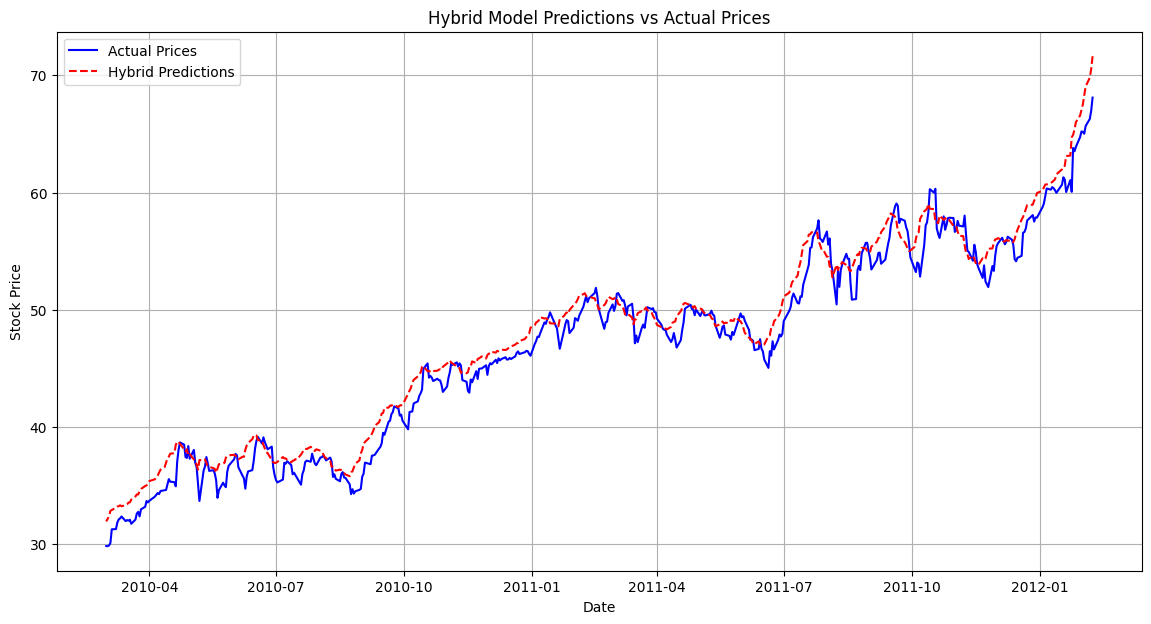

In [42]:
import matplotlib.pyplot as plt

# Inverse transform y_test to original scale for plotting
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Re-load the original dataframe to get the correct index for plotting
temp_df = pd.read_csv("apple_stock_data.csv")
temp_df.columns = temp_df.columns.str.strip()
if 'Date' in temp_df.columns:
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df.set_index('Date', inplace=True)

# The index for y_test corresponds to the original df starting from train_size + seq_lenght
plot_index = temp_df.index[train_size + seq_lenght:]

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Actual': y_test_inv.flatten(),
    'Hybrid_Predictions': hybrid_predictions.flatten()
}, index=plot_index)

plt.figure(figsize=(14, 7))
plt.plot(plot_df['Actual'], label='Actual Prices', color='blue')
plt.plot(plot_df['Hybrid_Predictions'], label='Hybrid Predictions', color='red', linestyle='--')
plt.title('Hybrid Model Predictions vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

The plot above visually compares the actual stock prices with the hybrid model's predictions. Ideally, the red dashed line (predictions) should closely follow the blue line (actuals). A visual inspection can reveal if the model is capturing trends and volatility well, or if there are significant deviations.